Para ejercitarte y afianzar lo aprendido sobre nuestra **Introducción a Deep Learning**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

# Bank marketing dataset - Depósito a plazo fijo

En este notebook vamos repasar un modelo que ya hicimos en anteriores ocasiones que nos permitía predecir si un individuo dependiendo de sus características, así como características de la campaña de marketing a la cual se pretende asignarlo, va a adquirir un servicio bancario (en este caso, un depósito a plazo fijo). El objetivo de este ejercicio será, mas allá de obtener un modelo preciso o hacer un análisis de datos exhaustivo, observar las posibles diferencias entre el utilizar un modelo de regresión logística o uno de MLP (multi-layer perceptron) para predecir nuestra variable categórica (sí adquiere, no adquiere).

Obtenemos los datos a partir del "*UCI Machine Learning repository*".

### *Features*:

#### Datos del cliente:

1. **age** (edad)
2. **job** (tipo de trabajo)
3. **marital** (estado marital)
4. **education** (nivel de eduación)
5. **default** (fallo en pagar una deuda)
6. **housing** (si tiene un préstamo de vivienda)
7. **loan** (si tiene un préstamo personal)
8. **balance** (balance personal)

#### Datos del último contacto de la campaña de marketing en curso:

9. **contact** (tipo de contacto)
10. **month** (último mes de contacto)
11. **day** (último día de contacto)
12. **duration** (duración de la llamada en segundos; duration = 0 significa no contactados)

#### Otros

13. **campaign** (número de contactos al cliente hechos en esta campaña)
14. **pdays** (número de días que han pasado desde que el cliente fue contactado en una campaña anterior; 999 o -1 significa que el cliente no ha sido contactado)
15. **previous** (número de contactos realizados antes de esta campaña a el cliente)
16. **poutcome** (resultado de la campaña anterior)
17. **deposit** (target)

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import time

from sklearn.metrics import classification_report

### Ejercicios 1

Importa los datos y echa un vistazo rápido. Selecciona la variable target y asignala a una variable "target".

In [2]:
df = pd.read_csv("./data/bank.csv")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
features = df.drop(["deposit"], axis = 1)
target = df["deposit"]

In [8]:
features.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome'],
      dtype='object')

In [9]:
target

0        yes
1        yes
2        yes
3        yes
4        yes
        ... 
11157     no
11158     no
11159     no
11160     no
11161     no
Name: deposit, Length: 11162, dtype: object

### Ejercicio 2

Haz el split en train y test y analiza el target.

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size= 0.2,
    random_state=42
)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8929, 16)
(2233, 16)
(8929,)
(2233,)


### Ejercicio 3

Tienes múltiples variables tipo object y algunas numéricas, en este caso quédate solo con las variables numéricas y el target. Observa las distribuciones de dichas variables numéricas

In [14]:
X_train_num = X_train.select_dtypes(include=['number'])
X_test_num = X_test.select_dtypes(include=['number'])

display(X_train_num.head())

,age,balance,day,duration,campaign,pdays,previous
3955,28,5741,10,1042,5,200,3
11150,34,355,21,314,3,-1,0
5173,48,201,10,594,1,91,1
3017,53,1961,15,351,1,-1,0
2910,53,1624,11,166,3,97,7


In [15]:
y_train_num = y_train.map({
    'yes' : 1,
    'no' : 0
})

In [16]:
y_train_num

3955     1
11150    0
5173     1
3017     1
2910     1
        ..
5734     0
5191     1
5390     0
860      1
7270     0
Name: deposit, Length: 8929, dtype: int64

In [17]:
y_test_num = y_test.map({
    'yes' : 1,
    'no' : 0
})

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

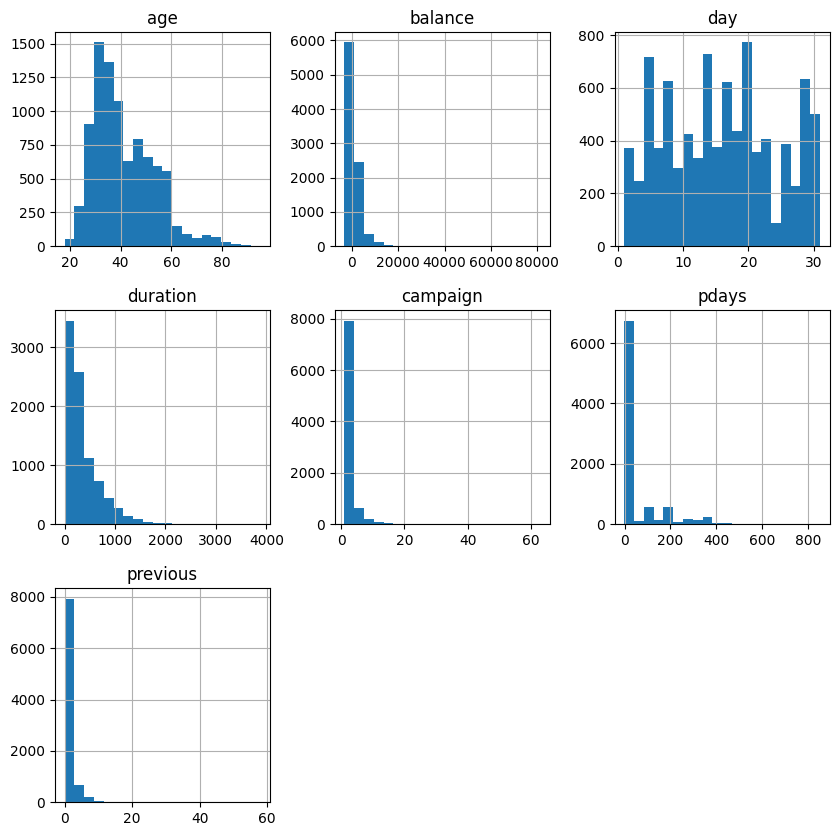

In [18]:
X_train_num.hist(
    figsize=(10,10),
    bins = 20
)

<Axes: >

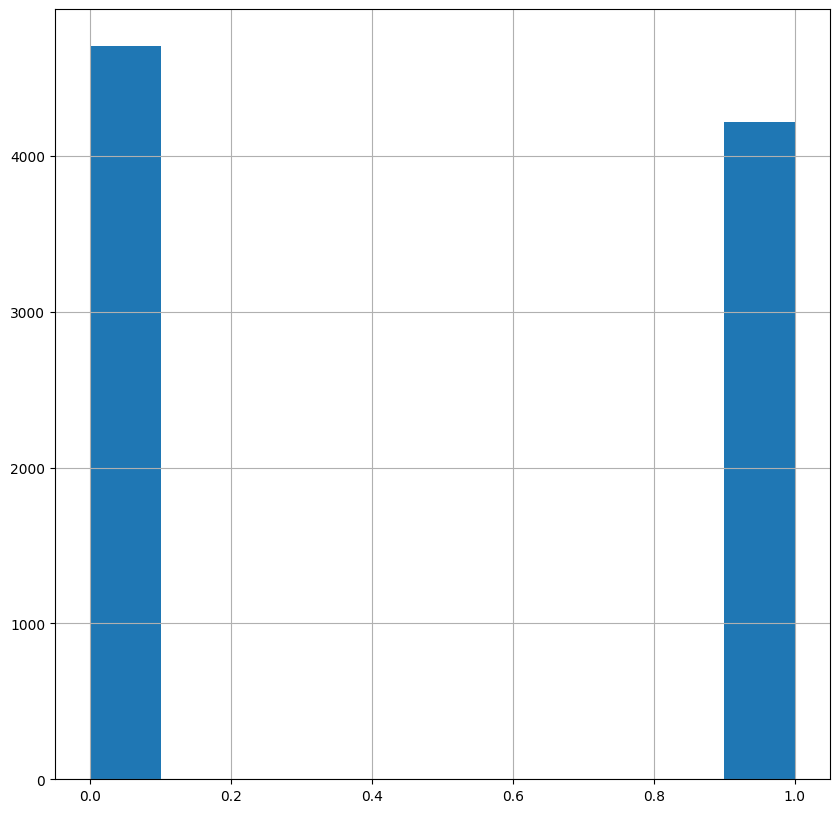

In [20]:
y_train_num.hist(
    figsize=(10,10)
)

### Ejercicio 4

A partir de las features del ejercicio 3, realiza una selección de features sencilla, utiliza la técnica que consideres conveniente y quedate con 4 features.

In [21]:
train_set_num = X_train_num.copy()
train_set_num['deposit_target'] = y_train_num

corr_matrix = train_set_num.corr()

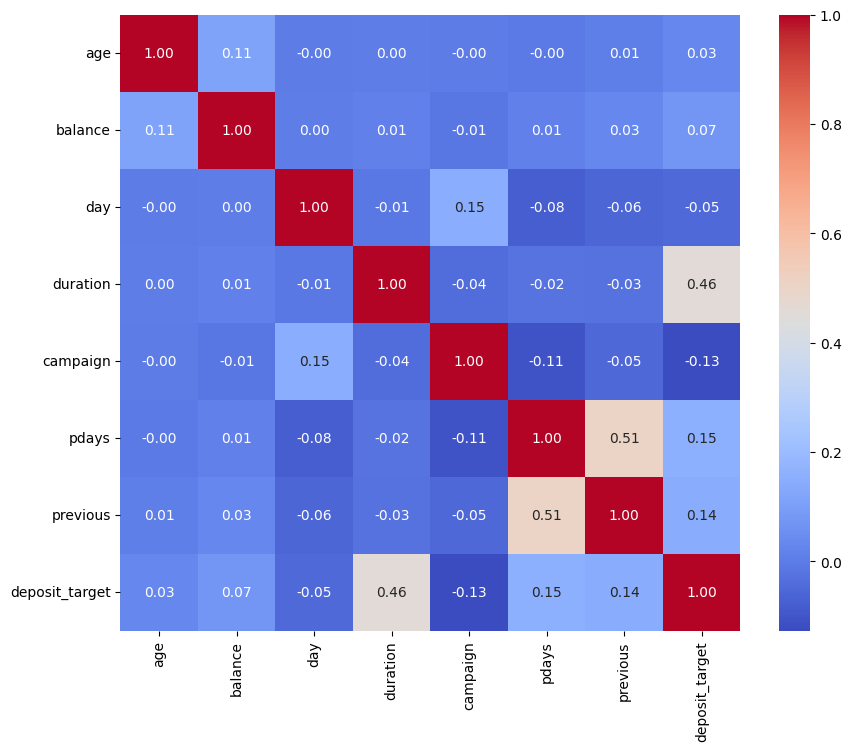

In [23]:
plt.figure(
    figsize=(10,8)
)

sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = ".2f"
)
plt.show()

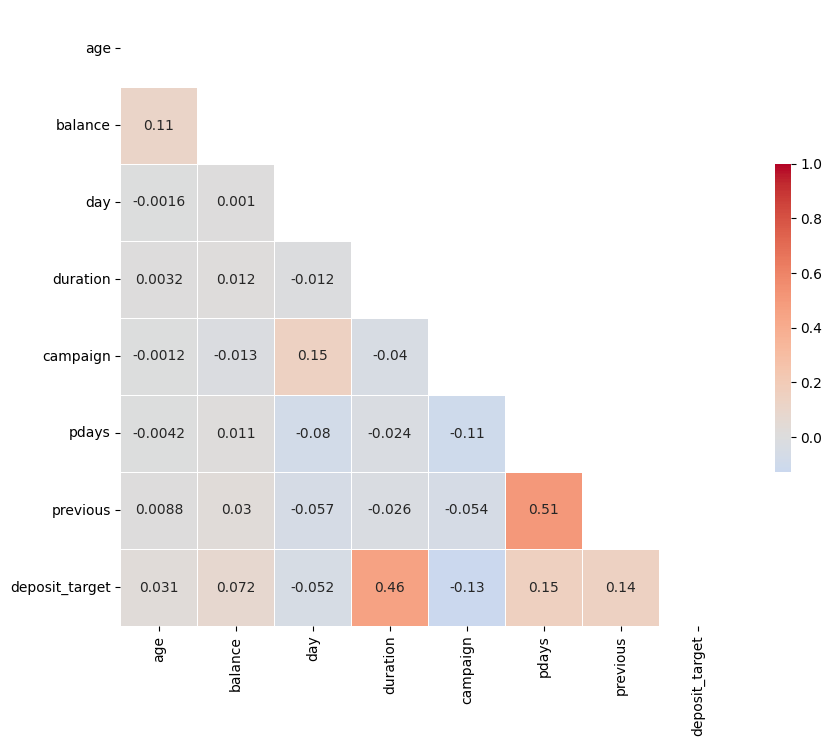

In [24]:
# Creamos la máscara para ocultar la parte superior triangular
# np.triu viene de "TRIangle Upper" (Triángulo Superior)
mask = np.triu(np.ones_like(corr_matrix , dtype=bool))

plt.figure(
    figsize=(10,8)
)

sns.heatmap(
            corr_matrix,
            mask=mask,           # Aquí aplicamos el recorte
            cmap='coolwarm',     # Paleta de colores (rojo/azul va genial)
            vmax=1,              # Valor máximo de la leyenda
            center=0,            # Centramos el color blanco en el 0
            square=True,         # Fuerza a que las celdas sean cuadradas
            linewidths=.5,       # Líneas blancas entre celdas para separar
            cbar_kws={"shrink": .5}, # Hace la barra de leyenda más pequeña
            annot=True)          # Muestra los números dentro

plt.show()

In [25]:
display(corr_matrix)

,age,balance,day,duration,campaign,pdays,previous,deposit_target
age,1.000000,0.113369,-0.001630,0.003161,-0.001236,-0.004222,0.008843,0.031209
balance,0.113369,1.000000,0.001037,0.011771,-0.013446,0.011381,0.030129,0.072000
day,-0.001630,0.001037,1.000000,-0.012018,0.149509,-0.079580,-0.056632,-0.051525
duration,0.003161,0.011771,-0.012018,1.000000,-0.039618,-0.023954,-0.026114,0.455134
campaign,-0.001236,-0.013446,0.149509,-0.039618,1.000000,-0.105376,-0.054396,-0.126892
pdays,-0.004222,0.011381,-0.079580,-0.023954,-0.105376,1.000000,0.506113,0.152436
previous,0.008843,0.030129,-0.056632,-0.026114,-0.054396,0.506113,1.000000,0.141661
deposit_target,0.031209,0.072000,-0.051525,0.455134,-0.126892,0.152436,0.141661,1.000000


In [27]:
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Configuración del selector
# k=4: queremos las 4 mejores
# f_classif: test ANOVA (mira si la media de la variable cambia mucho entre 'sí depósito' y 'no depósito')
selector = SelectKBest(
    score_func=f_classif, 
    k=4)

# 2. Entrenamos el selector
# OJO: X_train_num son tus variables numéricas filtradas
# OJO: y_train debe ser tu target (si ya lo pasaste a 0/1 mejor, aunque sklearn suele tragarse etiquetas de texto)
selector.fit(X_train_num, y_train_num)

# 3. ¿Cuáles ha elegido?
# .get_support() te devuelve una lista de True/False (True = elegida)
cols_seleccionadas = X_train_num.columns[selector.get_support()]

print("Las 4 fantásticas según SelectKBest son:")
print(cols_seleccionadas)

# 4. (Opcional) Ver las puntuaciones de cada una
scores = pd.DataFrame({'Feature': X_train_num.columns, 'Score': selector.scores_})
display(scores.sort_values(by='Score', ascending=False))

Las 4 fantásticas según SelectKBest son:
Index(['duration', 'campaign', 'pdays', 'previous'], dtype='object')


,Feature,Score
3,duration,2332.332261
5,pdays,212.370247
6,previous,182.815233
4,campaign,146.089961
1,balance,46.519070
2,day,23.762359
0,age,8.703400


### Ejercicio 5

Crea los pares X,y para train y test y escala los datos. ¿Por qué debemos hacerlo?

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_num)

X_test_scaled = scaler.fit_transform(X_test_num)


In [ ]:
#Convertimos de nuevo a DataFrame para que sea legible
# El scaler devuelve arrays de numpy, perdemos los nombres de las columnas
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_num.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test_num.columns)

In [31]:
X_train_scaled_df.head()

,age,balance,day,duration,campaign,pdays,previous
0,-1.114041,1.346271,-0.666669,1.941942,0.921804,1.374037,0.991722
1,-0.609278,-0.371778,0.635888,-0.162532,0.182456,-0.476209,-0.367601
2,0.568501,-0.420902,-0.666669,0.646881,-0.556892,0.370670,0.085506
3,0.989136,0.140511,-0.074597,-0.055574,-0.556892,-0.476209,-0.367601
4,0.989136,0.033013,-0.548255,-0.590364,0.182456,0.425901,2.804154


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

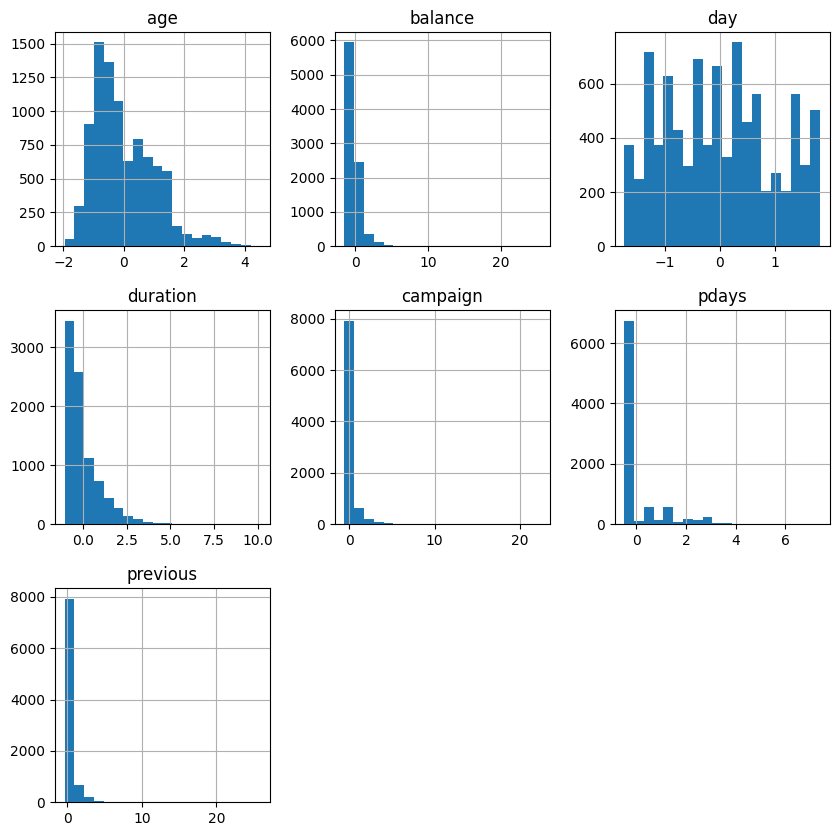

In [32]:
X_train_scaled_df.hist(
    figsize=(10,10),
    bins = 20
)

### Ejercicio 6

 Crea un modelo de regresión logistica y observa sus métricas. Además, registra su tiempo de entrenamiento y de predicciones

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

cols_top = ['duration', 'pdays', 'previous', 'campaign']

X_train_final = X_train_scaled_df[cols_top]
X_test_final = X_test_scaled_df[cols_top]

log_reg = LogisticRegression(
    random_state= 42
    )

start_train = time.time()
log_reg.fit(
    X_train_final,
    y_train_num
)
end_train = time.time()

log_train_time = end_train - start_train

start_pred = time.time()
y_pred = log_reg.predict(X_test_final)
end_pred = time.time()

log_pred_time = end_pred - start_pred


In [41]:
print(f"Accuracy del modelo: {accuracy_score(y_test_num, y_pred):.4f}")
print("\nInforme de clasificación:")
print(classification_report(y_test_num, y_pred))

Accuracy del modelo: 0.7358

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.72      0.82      0.76      1166
           1       0.76      0.65      0.70      1067

    accuracy                           0.74      2233
   macro avg       0.74      0.73      0.73      2233
weighted avg       0.74      0.74      0.73      2233



In [42]:
print(f"--- Regresión Logística ---")
print(f"Tiempo de entrenamiento: {log_train_time:.6f} segundos")
print(f"Tiempo de predicción:    {log_pred_time:.6f} segundos")

--- Regresión Logística ---
Tiempo de entrenamiento: 0.003546 segundos
Tiempo de predicción:    0.000738 segundos


### Ejercicio 7

Crea un modelo MLP, con sklearn, con dos hidden layers de 100 neuronas c/u y observa sus métricas. Además, registra su tiempo de entrenamiento y de predicciones

In [43]:
from sklearn.neural_network import MLPClassifier

# 1. Instanciamos el modelo
# hidden_layer_sizes=(100, 100) -> Dos capas ocultas de 100 neuronas cada una
# max_iter=1000 -> Aumentamos las iteraciones por si le cuesta converger (el default es 200)
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 100),
    max_iter = 1000,
    random_state= 42
)


start_train = time.time()
mlp.fit(X_train_final, y_train_num)
end_train = time.time()

train_time = end_train - start_train

start_pred = time.time()
y_pred_mlp = mlp.predict(X_test_final)
end_pred = time.time()

pred_time = end_pred - start_pred

In [44]:
print(f"Accuracy MLP: {accuracy_score(y_test_num, y_pred_mlp):.4f}")
print("\nInforme de clasificación MLP:")
print(classification_report(y_test_num, y_pred_mlp))

Accuracy MLP: 0.7627

Informe de clasificación MLP:
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      1166
           1       0.77      0.71      0.74      1067

    accuracy                           0.76      2233
   macro avg       0.76      0.76      0.76      2233
weighted avg       0.76      0.76      0.76      2233



In [45]:
print(f"Tiempo de entrenamiento: {train_time:.4f} segundos")
print(f"Tiempo de predicción:    {pred_time:.4f} segundos")
print("-" * 30)

Tiempo de entrenamiento: 1.0523 segundos
Tiempo de predicción:    0.0017 segundos
------------------------------


### Ejercicio 8

Compara los dos modelos. En un caso real, ¿Con cuál modelo te quedarías? ¿Por qué?

Regresión Logística: Rapidísima (microsegundos), pero simplona. Se le escapan matices.

MLP (Red Neuronal): Más lenta (segundos), pero más potente. Detecta patrones no lineales.

Si tuvieras una base de datos de 10 millones de clientes... ¿te compensaría el coste extra de computación del MLP para ganar ese 6% de clientes? (Spoiler: En banca, donde cada cliente vale dinero, la respuesta suele ser SÍ, siempre que el tiempo de entrenamiento sea asumible).